<a href="https://colab.research.google.com/github/Aaeeron/Bearing_live_expectancy/blob/main/IMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The dataset contains three separate data sets describing test-to-failure experiments. Instead of a single clean spreadsheet, the data is separated into hundreds of individual text files.

Set No. 2:

The Timeline: The motor ran continuously for several days.

The Files: There are 984 individual files. The file name indicates when the data was collected, with recordings taken at 10-minute intervals.

The Data: Each file is a 1-second vibration signal snapshot containing 20,480 points with the sampling rate set at 20 kHz.

The Outcome: At the end of the test-to-failure experiment, an outer race failure occurred in bearing 1.



In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Define Feature Extraction Logic ---
def extract_failing_bearing(folder_path, channel_index):
    """
    Reads files in a folder chronologically and extracts RMS and Kurtosis
    for a specific channel index corresponding to the failing bearing.
    """
    # Fix for nested folders created during extraction
    if os.path.exists(os.path.join(folder_path, os.path.basename(folder_path))):
        folder_path = os.path.join(folder_path, os.path.basename(folder_path))

    # Specific fix for 3rd_test which has an extra 'txt' folder
    if '3rd_test' in folder_path and os.path.exists(os.path.join(folder_path, 'txt')):
        folder_path = os.path.join(folder_path, 'txt')

    if not os.path.exists(folder_path):
        print(f"Warning: Folder '{folder_path}' not found.")
        return [], []

    valid_filepaths = []
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.endswith(('.txt', '.rar', '.DS_Store')):
                valid_filepaths.append(os.path.join(root, filename))

    valid_filepaths.sort(key=lambda x: os.path.basename(x))

    rms_values = []
    kurtosis_values = []

    for filepath in valid_filepaths:
        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
        except Exception:
            df = pd.read_csv(filepath, delim_whitespace=True, header=None)

        if df.shape[1] > channel_index:
            # Extract the specific channel where the failure occurred
            signal = df.iloc[:, channel_index].values
            rms_values.append(np.sqrt(np.mean(signal**2)))
            kurtosis_values.append(kurtosis(signal, fisher=False))

    return rms_values, kurtosis_values

# --- 3. Process the Data Directly from Google Drive ---
base_path = '/content/drive/MyDrive/Colab Notebooks'

print("Extracting Set 1 (1st_test) -> Bearing 3 (Channel 5 / Index 4)...")
rms_1, kurt_1 = extract_failing_bearing(f'{base_path}/1st_test', channel_index=4)

print("Extracting Set 2 (2nd_test) -> Bearing 1 (Channel 1 / Index 0)...")
rms_2, kurt_2 = extract_failing_bearing(f'{base_path}/2nd_test', channel_index=0)

print("Extracting Set 3 (3rd_test) -> Bearing 3 (Channel 3 / Index 2)...")
rms_3, kurt_3 = extract_failing_bearing(f'{base_path}/3rd_test', channel_index=2)


# --- 4. SAVE EXTRACTED DATA TO GOOGLE DRIVE ---
print("\nSaving extracted features to Drive...")

# Save Set 1
if rms_1:
    df_set1 = pd.DataFrame({'RMS': rms_1, 'Kurtosis': kurt_1})
    df_set1.to_csv(f'{base_path}/set1_features.csv', index=False)

# Save Set 2
if rms_2:
    df_set2 = pd.DataFrame({'RMS': rms_2, 'Kurtosis': kurt_2})
    df_set2.to_csv(f'{base_path}/set2_features.csv', index=False)

# Save Set 3
if rms_3:
    df_set3 = pd.DataFrame({'RMS': rms_3, 'Kurtosis': kurt_3})
    df_set3.to_csv(f'{base_path}/set3_features.csv', index=False)

print("Data successfully saved as CSVs!")


# --- 5. Generate Comparison Plots ---
print("\nGenerating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# Top Plot: RMS Comparison
if rms_1: ax1.plot(rms_1, label='Set 1 (Bearing 3)', color='tab:blue', linewidth=1.5)
if rms_2: ax1.plot(rms_2, label='Set 2 (Bearing 1)', color='tab:green', linewidth=1.5, alpha=0.8)
if rms_3: ax1.plot(rms_3, label='Set 3 (Bearing 3)', color='tab:cyan', linewidth=1.5, alpha=0.8)

ax1.set_title('RMS Degradation Curves (Targeting Actual Failures)', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMS Value (Overall Energy)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Kurtosis Comparison
if kurt_1: ax2.plot(kurt_1, label='Set 1 (Bearing 3)', color='tab:red', linewidth=1.5)
if kurt_2: ax2.plot(kurt_2, label='Set 2 (Bearing 1)', color='tab:purple', linewidth=1.5, alpha=0.8)
if kurt_3: ax2.plot(kurt_3, label='Set 3 (Bearing 3)', color='tab:orange', linewidth=1.5, alpha=0.8)

ax2.set_title('Kurtosis Degradation Curves (Targeting Actual Failures)', fontsize=14, fontweight='bold')
ax2.set_xlabel('File Index (Chronological Time)', fontsize=12)
ax2.set_ylabel('Kurtosis (Impacts/Spikiness)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting Set 1 (1st_test) -> Bearing 3 (Channel 5 / Index 4)...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Colab Notebooks'

# Load the features instantly
df_set1 = pd.read_csv(f'{base_path}/set1_features.csv')
df_set2 = pd.read_csv(f'{base_path}/set2_features.csv')
df_set3 = pd.read_csv(f'{base_path}/set3_features.csv')

# Extract back to lists for plotting or modeling
rms_1, kurt_1 = df_set1['RMS'].tolist(), df_set1['Kurtosis'].tolist()
rms_2, kurt_2 = df_set2['RMS'].tolist(), df_set2['Kurtosis'].tolist()
rms_3, kurt_3 = df_set3['RMS'].tolist(), df_set3['Kurtosis'].tolist()

print("Features loaded from Drive instantly!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Features loaded from Drive instantly!



Normalizing data to healthy baselines...
Generating normalized plots...


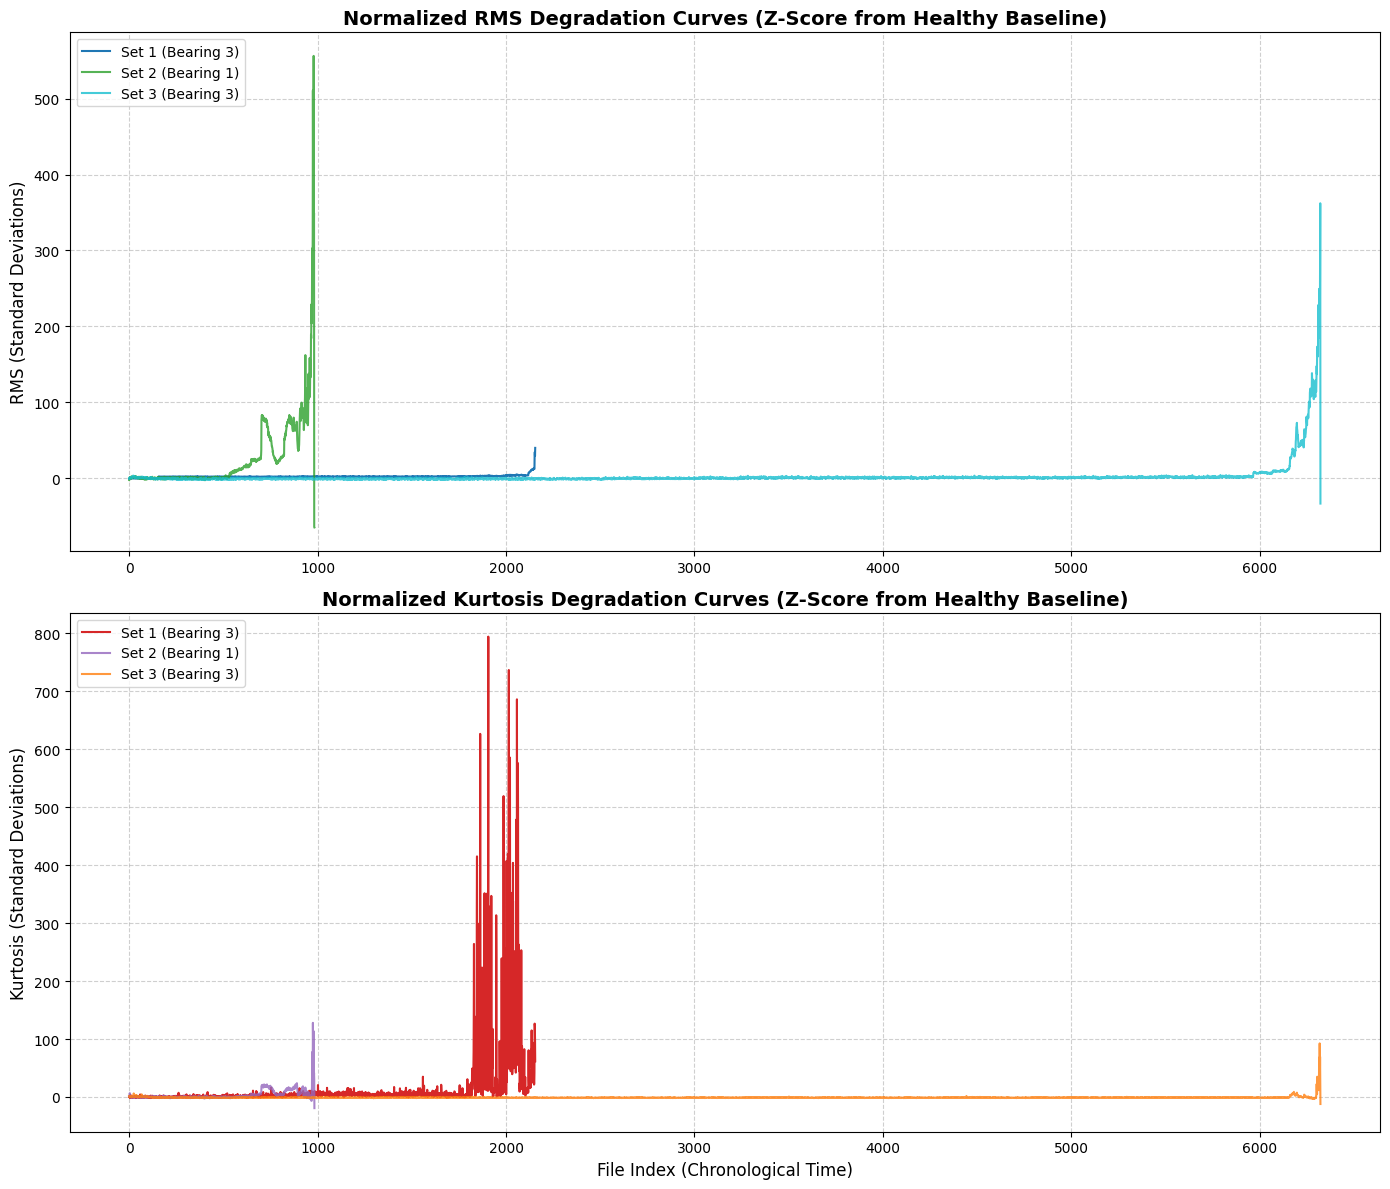

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis# --- 4. Apply Healthy Baseline Normalization ---
def normalize_to_baseline(feature_array, baseline_window=200):
    """
    Normalizes an array based on the mean and standard deviation
    of its initial 'healthy' state (first N files).
    """
    if len(feature_array) == 0:
        return []

    feature_array = np.array(feature_array)
    healthy_baseline = feature_array[:baseline_window]

    mu = np.mean(healthy_baseline)
    sigma = np.std(healthy_baseline)

    # Prevent division by zero
    if sigma == 0:
        sigma = 1e-8

    normalized_array = (feature_array - mu) / sigma
    return normalized_array

print("\nNormalizing data to healthy baselines...")
rms_1_norm = normalize_to_baseline(rms_1)
rms_2_norm = normalize_to_baseline(rms_2)
rms_3_norm = normalize_to_baseline(rms_3)

kurt_1_norm = normalize_to_baseline(kurt_1)
kurt_2_norm = normalize_to_baseline(kurt_2)
kurt_3_norm = normalize_to_baseline(kurt_3)

# --- 5. Generate Normalized Comparison Plots ---
print("Generating normalized plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# Top Plot: Normalized RMS Comparison
if len(rms_1_norm) > 0: ax1.plot(rms_1_norm, label='Set 1 (Bearing 3)', color='tab:blue', linewidth=1.5)
if len(rms_2_norm) > 0: ax1.plot(rms_2_norm, label='Set 2 (Bearing 1)', color='tab:green', linewidth=1.5, alpha=0.8)
if len(rms_3_norm) > 0: ax1.plot(rms_3_norm, label='Set 3 (Bearing 3)', color='tab:cyan', linewidth=1.5, alpha=0.8)

ax1.set_title('Normalized RMS Degradation Curves (Z-Score from Healthy Baseline)', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMS (Standard Deviations)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Normalized Kurtosis Comparison
if len(kurt_1_norm) > 0: ax2.plot(kurt_1_norm, label='Set 1 (Bearing 3)', color='tab:red', linewidth=1.5)
if len(kurt_2_norm) > 0: ax2.plot(kurt_2_norm, label='Set 2 (Bearing 1)', color='tab:purple', linewidth=1.5, alpha=0.8)
if len(kurt_3_norm) > 0: ax2.plot(kurt_3_norm, label='Set 3 (Bearing 3)', color='tab:orange', linewidth=1.5, alpha=0.8)

ax2.set_title('Normalized Kurtosis Degradation Curves (Z-Score from Healthy Baseline)', fontsize=14, fontweight='bold')
ax2.set_xlabel('File Index (Chronological Time)', fontsize=12)
ax2.set_ylabel('Kurtosis (Standard Deviations)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Define Feature Extraction Logic ---
def extract_failing_bearing(folder_path, channel_index):
    """
    Reads files in a folder chronologically and extracts RMS and Kurtosis
    for a specific channel index corresponding to the failing bearing.
    """
    # Fix for nested folders created during extraction
    if os.path.exists(os.path.join(folder_path, os.path.basename(folder_path))):
        folder_path = os.path.join(folder_path, os.path.basename(folder_path))

    # Specific fix for 3rd_test which has an extra 'txt' folder
    if '3rd_test' in folder_path and os.path.exists(os.path.join(folder_path, 'txt')):
        folder_path = os.path.join(folder_path, 'txt')

    if not os.path.exists(folder_path):
        print(f"Warning: Folder '{folder_path}' not found.")
        return [], []

    valid_filepaths = []
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.endswith(('.txt', '.rar', '.DS_Store')):
                valid_filepaths.append(os.path.join(root, filename))

    valid_filepaths.sort(key=lambda x: os.path.basename(x))

    rms_values = []
    kurtosis_values = []

    for filepath in valid_filepaths:
        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
        except Exception:
            df = pd.read_csv(filepath, delim_whitespace=True, header=None)

        if df.shape[1] > channel_index:
            # Extract the specific channel where the failure occurred
            signal = df.iloc[:, channel_index].values
            rms_values.append(np.sqrt(np.mean(signal**2)))
            kurtosis_values.append(kurtosis(signal, fisher=False))

    return rms_values, kurtosis_values

# --- 3. Process the Data Directly from Google Drive ---
base_path = '/content/drive/MyDrive/Colab Notebooks'

print("Extracting Set 1 (1st_test) -> Bearing 3 (Channel 5 / Index 4)...")
rms_1, kurt_1 = extract_failing_bearing(f'{base_path}/1st_test', channel_index=4)

print("Extracting Set 2 (2nd_test) -> Bearing 1 (Channel 1 / Index 0)...")
rms_2, kurt_2 = extract_failing_bearing(f'{base_path}/2nd_test', channel_index=0)

print("Extracting Set 3 (3rd_test) -> Bearing 3 (Channel 3 / Index 2)...")
rms_3, kurt_3 = extract_failing_bearing(f'{base_path}/3rd_test', channel_index=2)


# --- 4. SAVE EXTRACTED DATA TO GOOGLE DRIVE ---
print("\nSaving extracted features to Drive...")

# Save Set 1
if rms_1:
    df_set1 = pd.DataFrame({'RMS': rms_1, 'Kurtosis': kurt_1})
    df_set1.to_csv(f'{base_path}/set1_features.csv', index=False)

# Save Set 2
if rms_2:
    df_set2 = pd.DataFrame({'RMS': rms_2, 'Kurtosis': kurt_2})
    df_set2.to_csv(f'{base_path}/set2_features.csv', index=False)

# Save Set 3
if rms_3:
    df_set3 = pd.DataFrame({'RMS': rms_3, 'Kurtosis': kurt_3})
    df_set3.to_csv(f'{base_path}/set3_features.csv', index=False)

print("Data successfully saved as CSVs!")


# --- 5. Generate Comparison Plots ---
print("\nGenerating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# Top Plot: RMS Comparison
if rms_1: ax1.plot(rms_1, label='Set 1 (Bearing 3)', color='tab:blue', linewidth=1.5)
if rms_2: ax1.plot(rms_2, label='Set 2 (Bearing 1)', color='tab:green', linewidth=1.5, alpha=0.8)
if rms_3: ax1.plot(rms_3, label='Set 3 (Bearing 3)', color='tab:cyan', linewidth=1.5, alpha=0.8)

ax1.set_title('RMS Degradation Curves (Targeting Actual Failures)', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMS Value (Overall Energy)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Kurtosis Comparison
if kurt_1: ax2.plot(kurt_1, label='Set 1 (Bearing 3)', color='tab:red', linewidth=1.5)
if kurt_2: ax2.plot(kurt_2, label='Set 2 (Bearing 1)', color='tab:purple', linewidth=1.5, alpha=0.8)
if kurt_3: ax2.plot(kurt_3, label='Set 3 (Bearing 3)', color='tab:orange', linewidth=1.5, alpha=0.8)

ax2.set_title('Kurtosis Degradation Curves (Targeting Actual Failures)', fontsize=14, fontweight='bold')
ax2.set_xlabel('File Index (Chronological Time)', fontsize=12)
ax2.set_ylabel('Kurtosis (Impacts/Spikiness)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting Set 1 (1st_test) -> Bearing 3 (Channel 5 / Index 4)...
Extracting Set 2 (2nd_test) -> Bearing 1 (Channel 1 / Index 0)...
Extracting Set 3 (3rd_test) -> Bearing 3 (Channel 3 / Index 2)...


KeyboardInterrupt: 

Folder (Dataset),Total Files (Time Snapshots),Channels per File,Which Bearing Reached EOL?,Type of Failure (EOL)
Set 1 (1st_test),"2,156 files",8 (2 sensors per bearing),Bearing 3 & Bearing 4,Inner race (B3) & Roller element (B4)
Set 2 (2nd_test),984 files,4 (1 sensor per bearing),Bearing 1,Outer race
Set 3 (3rd_test),"4,448 files",4 (1 sensor per bearing),Bearing 3,Outer race

Calculating Frequency Spectrums (FFT) across datasets...


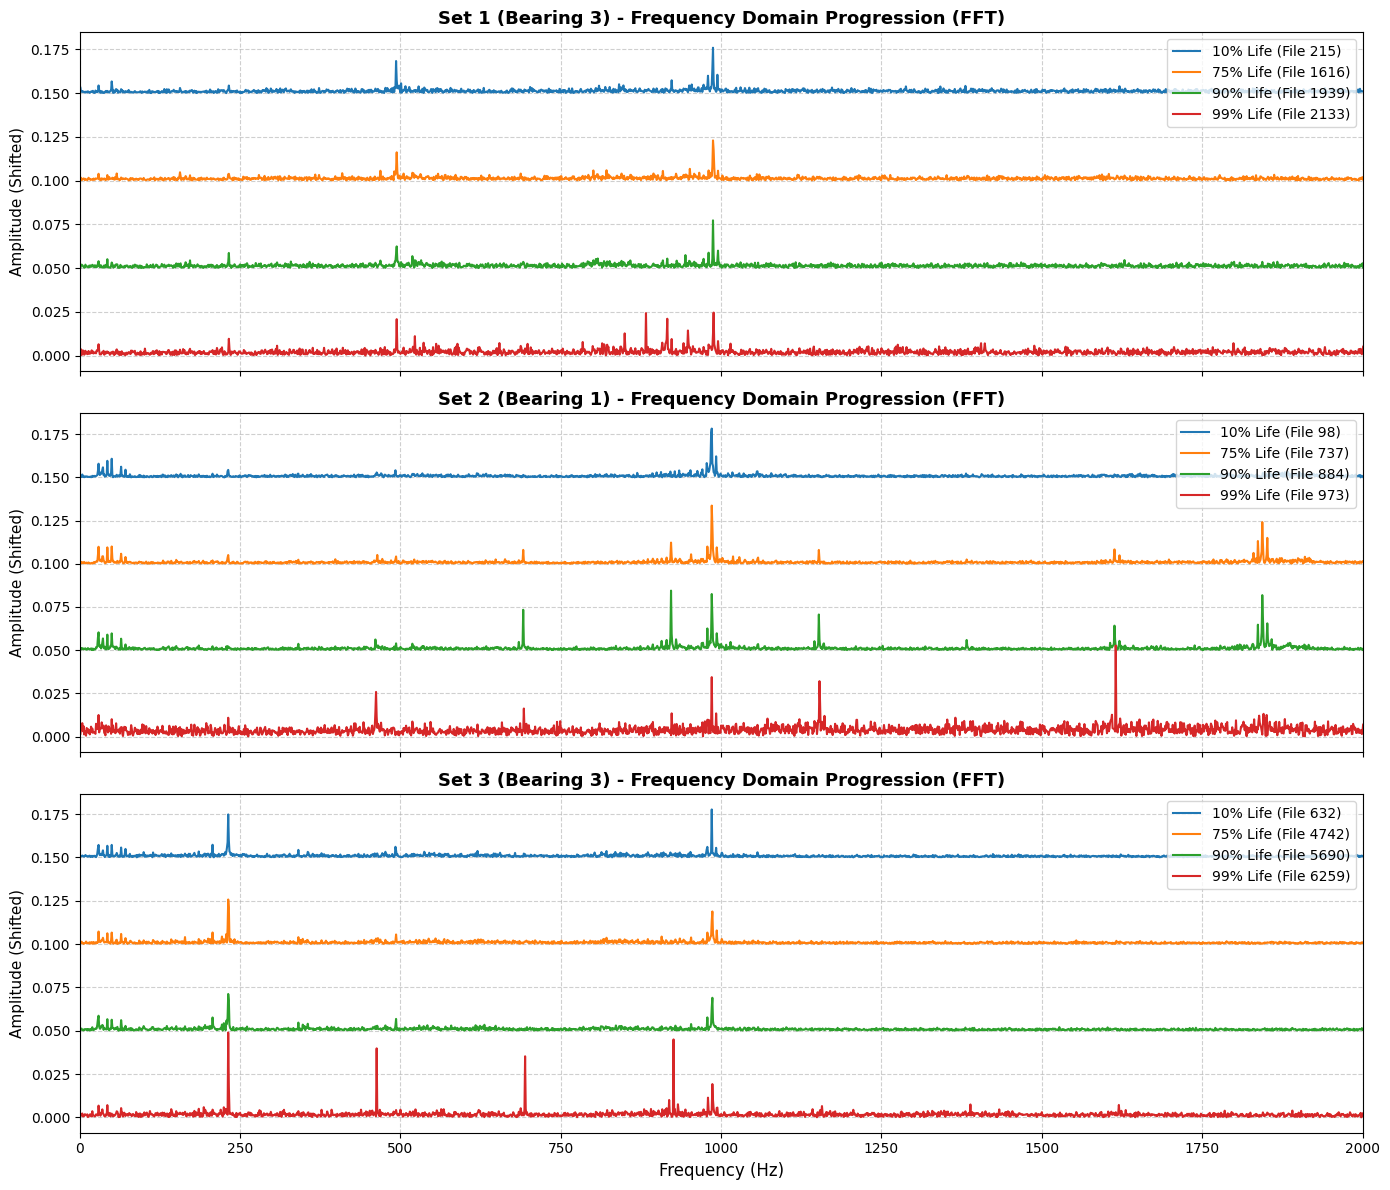

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def plot_multi_dataset_fft(datasets_info, life_stages=[0.10, 0.50, 0.90, 0.99]):
    """
    Compares the frequency domain of multiple datasets at relative stages of life.
    life_stages: List of percentages (0.0 to 1.0) representing the dataset's lifespan.
    """
    print("Calculating Frequency Spectrums (FFT) across datasets...")

    fs = 20000      # Sampling rate: 20 kHz
    n_points = 20480  # Points per file

    fig, axes = plt.subplots(len(datasets_info), 1, figsize=(14, 4 * len(datasets_info)), sharex=True)
    if len(datasets_info) == 1: axes = [axes]

    for ax, (ds_name, info) in zip(axes, datasets_info.items()):
        folder_path = info['path']
        col_idx = info['col']

        if not os.path.exists(folder_path):
            ax.text(0.5, 0.5, f"Folder {folder_path} not found.\nPlease check the path.", ha='center', va='center')
            continue

        # Filter out directories and hidden files just in case
        file_names = sorted([f for f in os.listdir(folder_path)
                             if os.path.isfile(os.path.join(folder_path, f)) and not f.startswith('.')])

        total_files = len(file_names)

        if total_files == 0:
            ax.text(0.5, 0.5, f"No files found in {folder_path}.", ha='center', va='center')
            continue

        for idx, pct in enumerate(life_stages):
            file_idx = int(pct * (total_files - 1))
            filename = file_names[file_idx]
            filepath = os.path.join(folder_path, filename)

            try:
                df = pd.read_csv(filepath, sep='\t', header=None)
            except Exception:
                df = pd.read_csv(filepath, delim_whitespace=True, header=None)

            signal = df.iloc[:, col_idx].values

            fft_values = fft(signal)
            frequencies = fftfreq(n_points, 1/fs)

            pos_mask = frequencies > 0
            freqs_pos = frequencies[pos_mask]
            magnitude = np.abs(fft_values[pos_mask]) * 2.0 / n_points

            offset = (len(life_stages) - idx - 1) * 0.05

            label_str = f'{pct*100:.0f}% Life (File {file_idx})'
            ax.plot(freqs_pos, magnitude + offset, label=label_str, linewidth=1.5)

        ax.set_title(f'{ds_name} - Frequency Domain Progression (FFT)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Amplitude (Shifted)', fontsize=11)
        ax.set_xlim(0, 2000)
        ax.legend(loc='upper right', framealpha=0.8)
        ax.grid(True, linestyle='--', alpha=0.6)

    axes[-1].set_xlabel('Frequency (Hz)', fontsize=12)

    fig.tight_layout()
    plt.show()

# UPDATED PATHS for the FFT script
base_path = '/content/drive/MyDrive/Colab Notebooks'

datasets = {
    'Set 1 (Bearing 3)': {'path': f'{base_path}/1st_test/1st_test', 'col': 4},
    'Set 2 (Bearing 1)': {'path': f'{base_path}/2nd_test/2nd_test', 'col': 0},
    'Set 3 (Bearing 3)': {'path': f'{base_path}/3rd_test/4th_test/txt', 'col': 2}
}

milestone_stages = [0.10, 0.75, 0.90, 0.99]

plot_multi_dataset_fft(datasets, milestone_stages)

Calculating baseline for Set 1 (Bearing 3 - Inner)...
Calculating baseline for Set 2 (Bearing 1 - Outer)...
Calculating baseline for Set 3 (Bearing 3 - Outer)...


/tmp/ipykernel_582/999049401.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


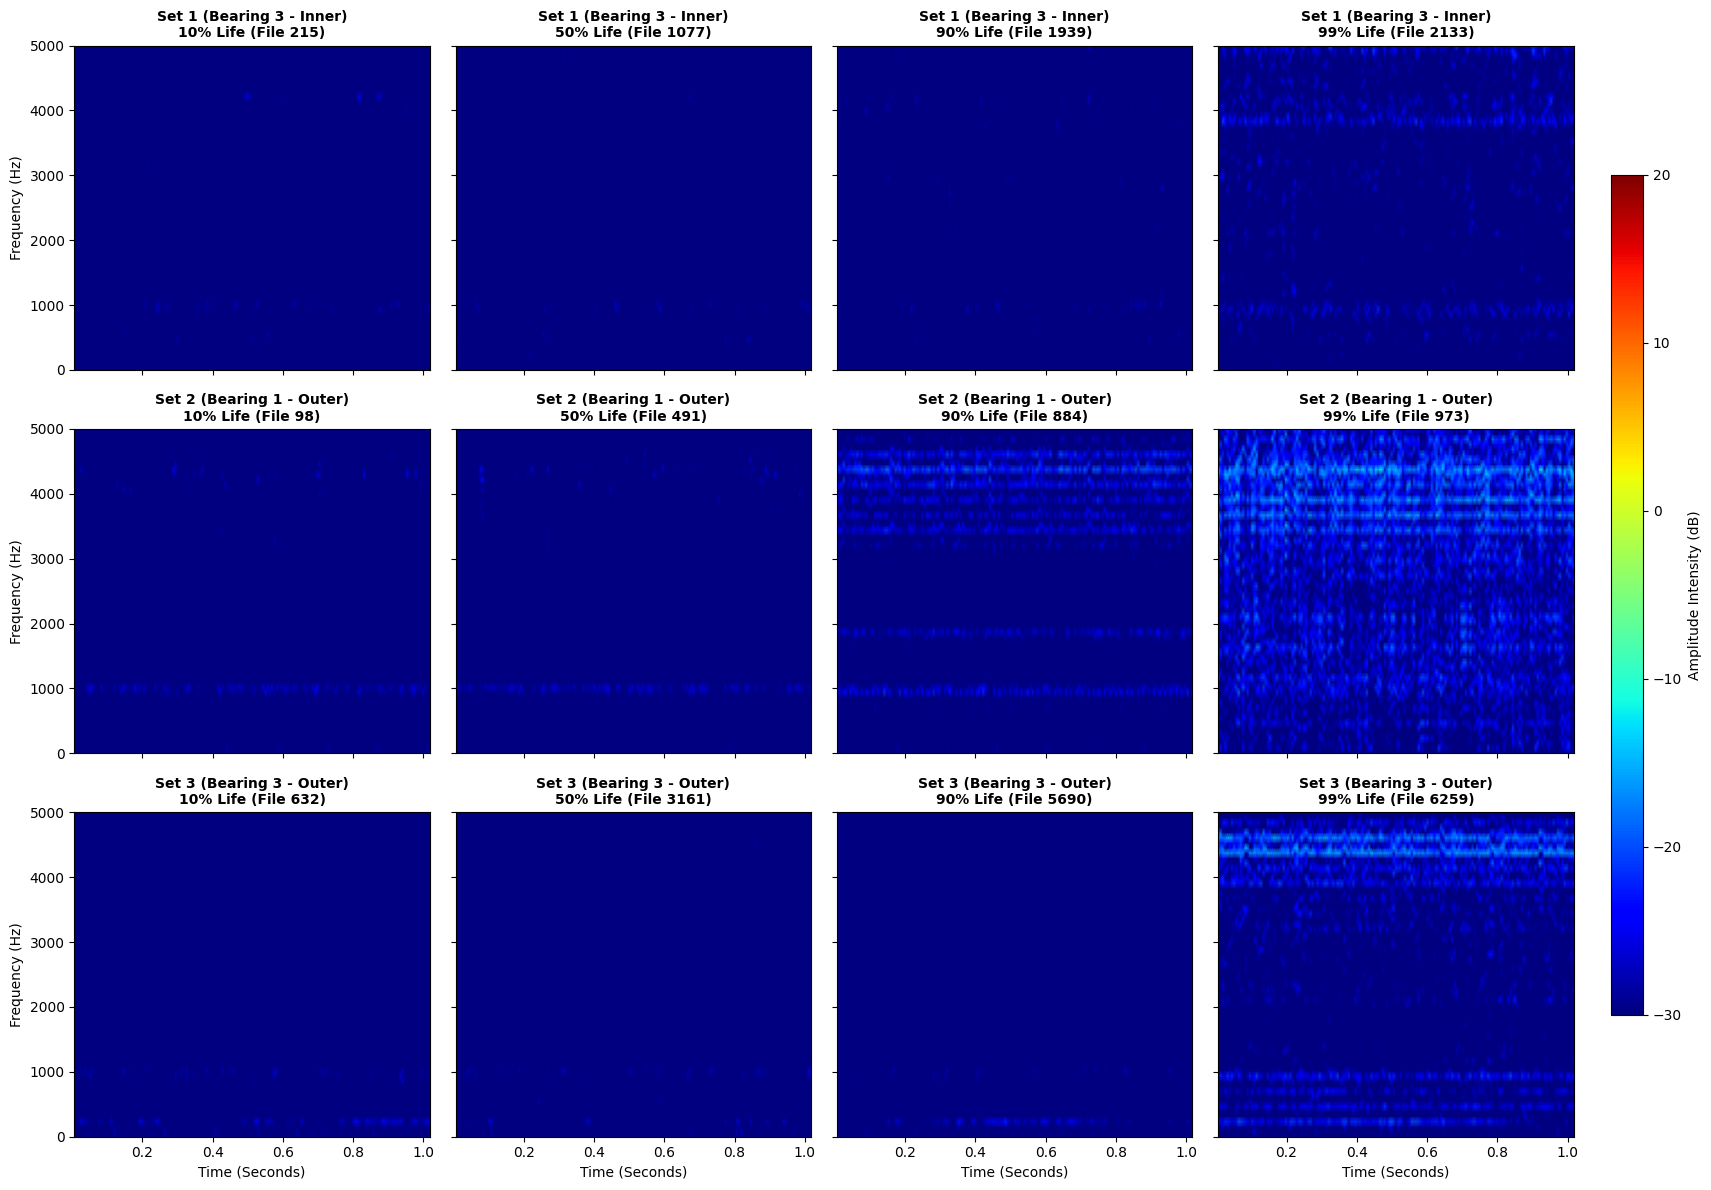

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# --- 1. Helper Function: Handle Nested Folders ---
def get_clean_folder_path(folder_path):
    if '3rd_test' in folder_path:
        deep_path = os.path.join(folder_path, '4th_test', 'txt')
        if os.path.exists(deep_path):
            return deep_path

        # Fallback if it's just 3rd_test -> 4th_test
        mid_path = os.path.join(folder_path, '4th_test')
        if os.path.exists(mid_path):
            return mid_path

        # Fallback if it's just 3rd_test -> txt
        txt_path = os.path.join(folder_path, 'txt')
        if os.path.exists(txt_path):
            return txt_path

    # Fix for standard nested folders with the same name (e.g., 1st_test/1st_test)
    if os.path.exists(os.path.join(folder_path, os.path.basename(folder_path))):
        return os.path.join(folder_path, os.path.basename(folder_path))

    return folder_path
# --- 2. Baseline Normalization Extractor ---
def calculate_healthy_baseline(folder_path, channel_index, baseline_files_count=20):
    """Calculates the mean and std deviation from the first N 'healthy' files."""
    folder_path = get_clean_folder_path(folder_path)

    if not os.path.exists(folder_path):
        return 0, 1, [] # <-- FIXED: Added an empty list for file_list

    valid_filepaths = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path)
                              if not f.startswith('.') and os.path.isfile(os.path.join(folder_path, f))])

    healthy_data = []
    for filepath in valid_filepaths[:baseline_files_count]:
        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
        except Exception:
            df = pd.read_csv(filepath, delim_whitespace=True, header=None)

        if df.shape[1] > channel_index:
            healthy_data.extend(df.iloc[:, channel_index].values)

    healthy_data = np.array(healthy_data)
    mu = np.mean(healthy_data)
    sigma = np.std(healthy_data)

    # Prevent division by zero
    if sigma == 0: sigma = 1e-8

    return mu, sigma, valid_filepaths

# --- 3. Main Plotting Function ---
def plot_spectrogram_grid(datasets_info, life_stages=[0.10, 0.50, 0.90, 0.99]):
    fs = 20000 # 20 kHz sampling frequency

    fig, axes = plt.subplots(len(datasets_info), len(life_stages),
                             figsize=(16, 4 * len(datasets_info)), sharex=True, sharey=True)

    mesh = None # <-- FIXED: Initialize mesh to None

    for row, (ds_name, info) in enumerate(datasets_info.items()):
        folder_path = info['path']
        col_idx = info['col']

        print(f"Calculating baseline for {ds_name}...")
        mu, sigma, file_list = calculate_healthy_baseline(folder_path, col_idx)
        total_files = len(file_list)

        if total_files == 0:
            print(f"Skipping {ds_name} - no files found.")
            continue

        for col, pct in enumerate(life_stages):
            ax = axes[row, col] if len(datasets_info) > 1 else axes[col] # handle 1D vs 2D axes

            # Fetch the specific file based on life percentage
            file_idx = int(pct * (total_files - 1))
            filepath = file_list[file_idx]

            try:
                df = pd.read_csv(filepath, sep='\t', header=None)
            except Exception:
                df = pd.read_csv(filepath, delim_whitespace=True, header=None)

            raw_signal = df.iloc[:, col_idx].values

            # --- APPLY HEALTHY BASELINE NORMALIZATION ---
            normalized_signal = (raw_signal - mu) / sigma

            # --- GENERATE SPECTROGRAM (STFT) ---
            f, t, Sxx = spectrogram(normalized_signal, fs=fs, nperseg=256, noverlap=128)
            Sxx_dB = 10 * np.log10(Sxx + 1e-10)

            # Plot the 2D Matrix
            mesh = ax.pcolormesh(t, f, Sxx_dB, shading='gouraud', cmap='jet', vmin=-30, vmax=20)

            ax.set_title(f"{ds_name}\n{pct*100:.0f}% Life (File {file_idx})", fontsize=10, fontweight='bold')

            if row == len(datasets_info) - 1:
                ax.set_xlabel('Time (Seconds)', fontsize=10)
            if col == 0:
                ax.set_ylabel('Frequency (Hz)', fontsize=10)

            ax.set_ylim(0, 5000)

    # <-- FIXED: Only draw colorbar if mesh was successfully created
    if mesh is not None:
        cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])
        fig.colorbar(mesh, cax=cbar_ax, label='Amplitude Intensity (dB)')

    fig.tight_layout()
    plt.show()

# --- 4. Execution ---
# <-- FIXED: Corrected your base path to point to your Drive folder
base_path = '/content/drive/MyDrive/Colab Notebooks'

datasets = {
    'Set 1 (Bearing 3 - Inner)': {'path': f'{base_path}/1st_test', 'col': 4},
    'Set 2 (Bearing 1 - Outer)': {'path': f'{base_path}/2nd_test', 'col': 0},
    'Set 3 (Bearing 3 - Outer)': {'path': f'{base_path}/3rd_test', 'col': 2}
}

milestone_stages = [0.10, 0.50, 0.90, 0.99]

plot_spectrogram_grid(datasets, milestone_stages)



# IMS Bearing Run-to-Failure Dataset

## Experiment Overview
This dataset, provided by the Center for Intelligent Maintenance Systems (IMS) at the University of Cincinnati and hosted by the NASA Prognostics Data Repository, contains run-to-failure vibration data. The experiment was designed to capture the natural degradation of bearings from a healthy state to catastrophic failure.

## Test Rig Specifications
*   **Bearings:** 4 Rexnord ZA-2115 double-row bearings installed on a single shaft.
*   **Operating Speed:** Constant 2,000 RPM.
*   **Radial Load:** 6,000 lbs applied to the shaft and bearings via a spring mechanism.

## Data Acquisition Parameters
*   **Sampling Rate:** 20 kHz (20,000 data points per second).
*   **Snapshot Duration:** 1-second vibration signal snapshots containing 20,480 data points per file.
*   **Recording Interval:** Snapshots were generally recorded every 10 minutes.

## Dataset Failure Modes
The dataset is divided into three distinct run-to-failure tests, each resulting in a different defect:
*   **Set 1:** Bearing 3 developed an **Inner Race defect**.
*   **Set 2:** Bearing 1 developed an **Outer Race defect**.
*   **Set 3:** Bearing 3 developed an **Outer Race defect**.

Loading data for Set 1 (Bearing 3 - Inner)...


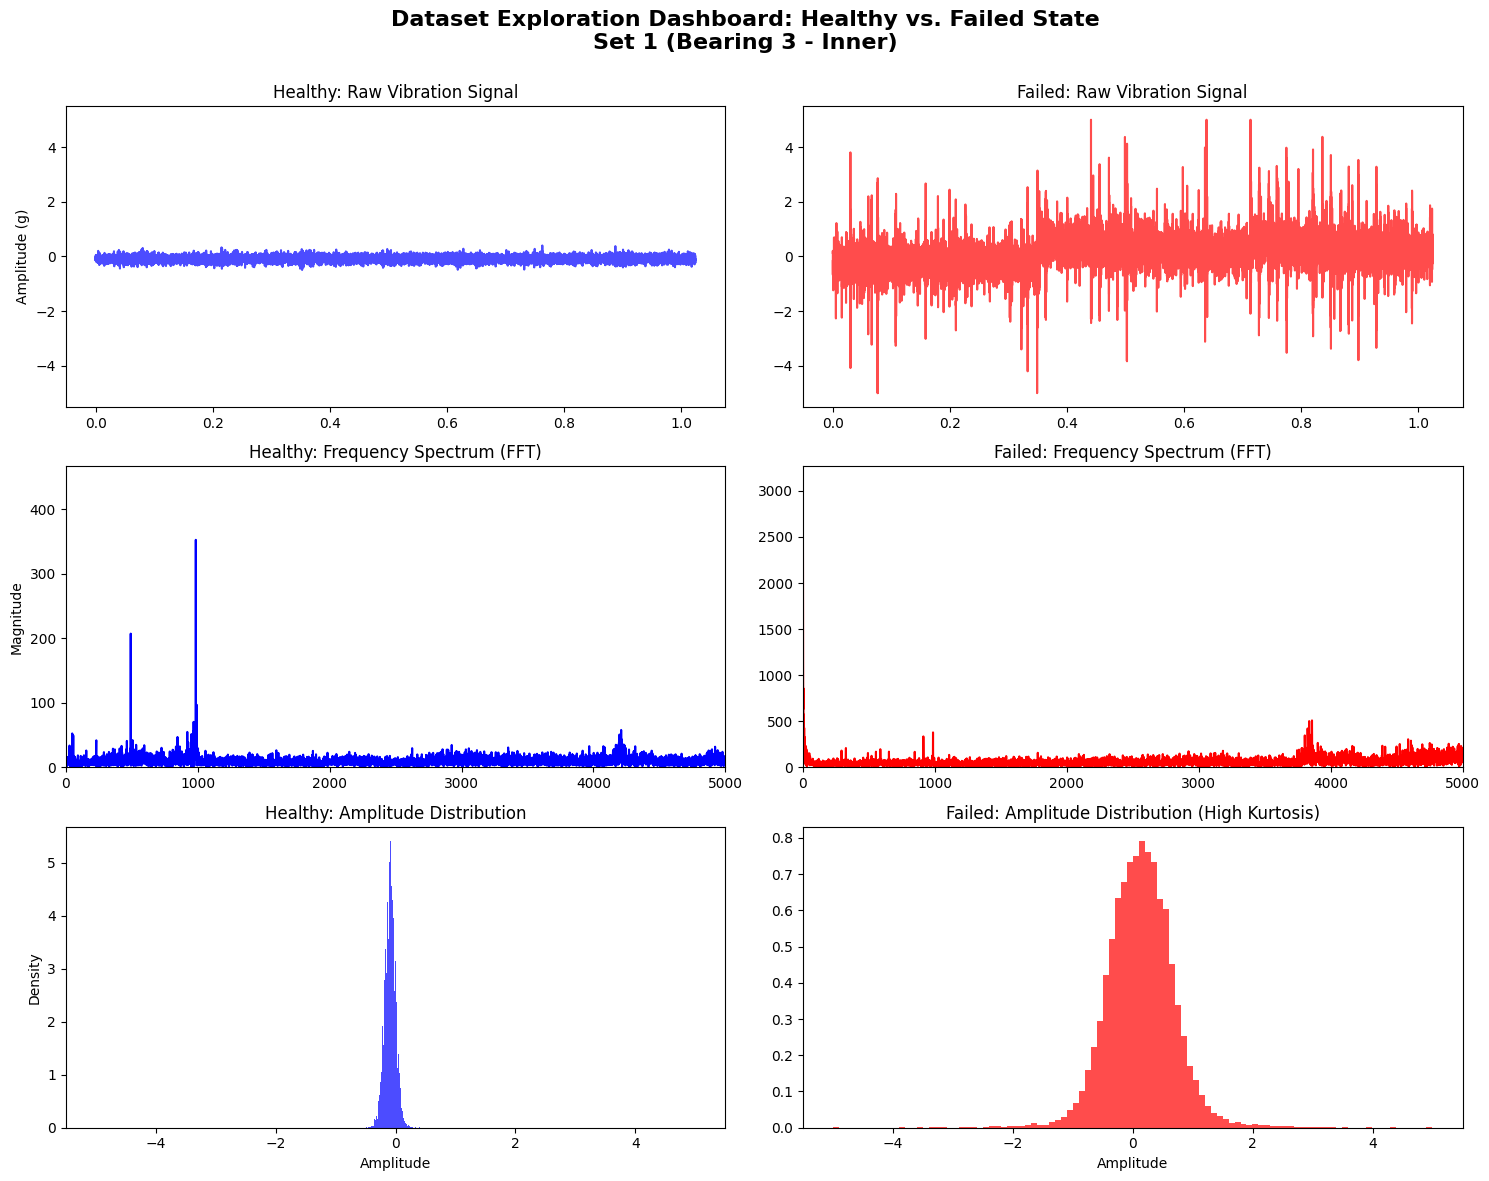

Loading data for Set 2 (Bearing 1 - Outer)...


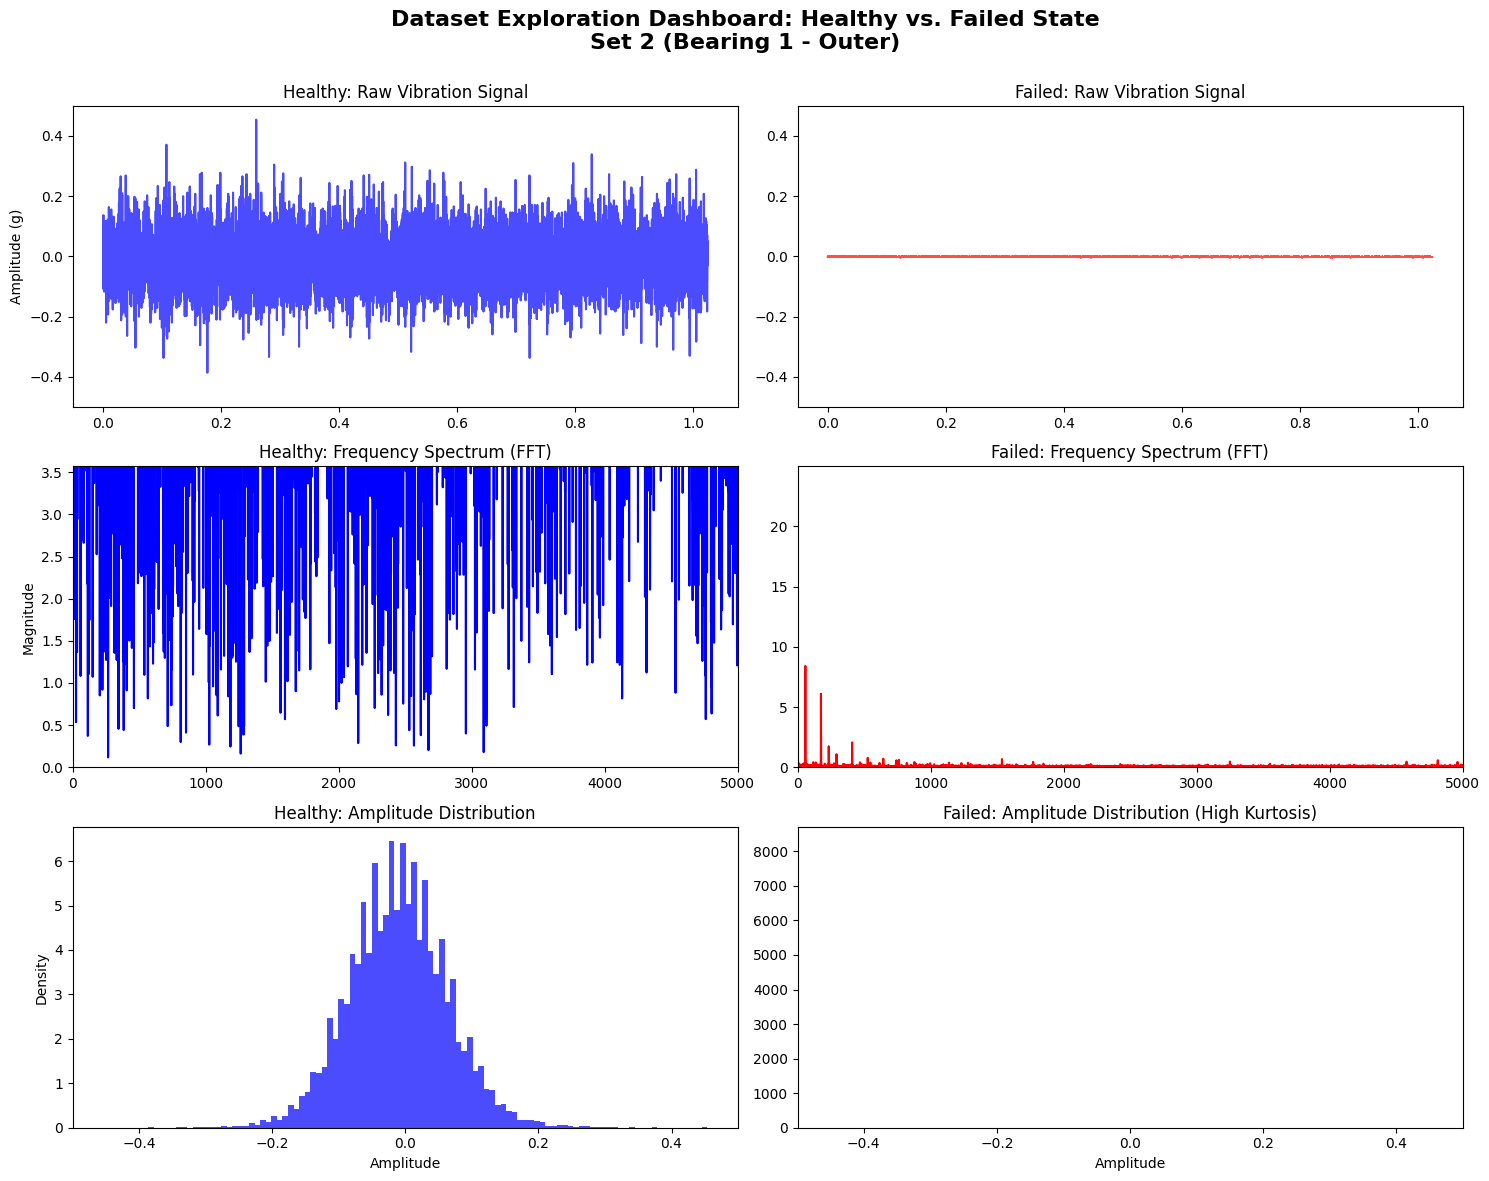

Loading data for Set 3 (Bearing 3 - Outer)...


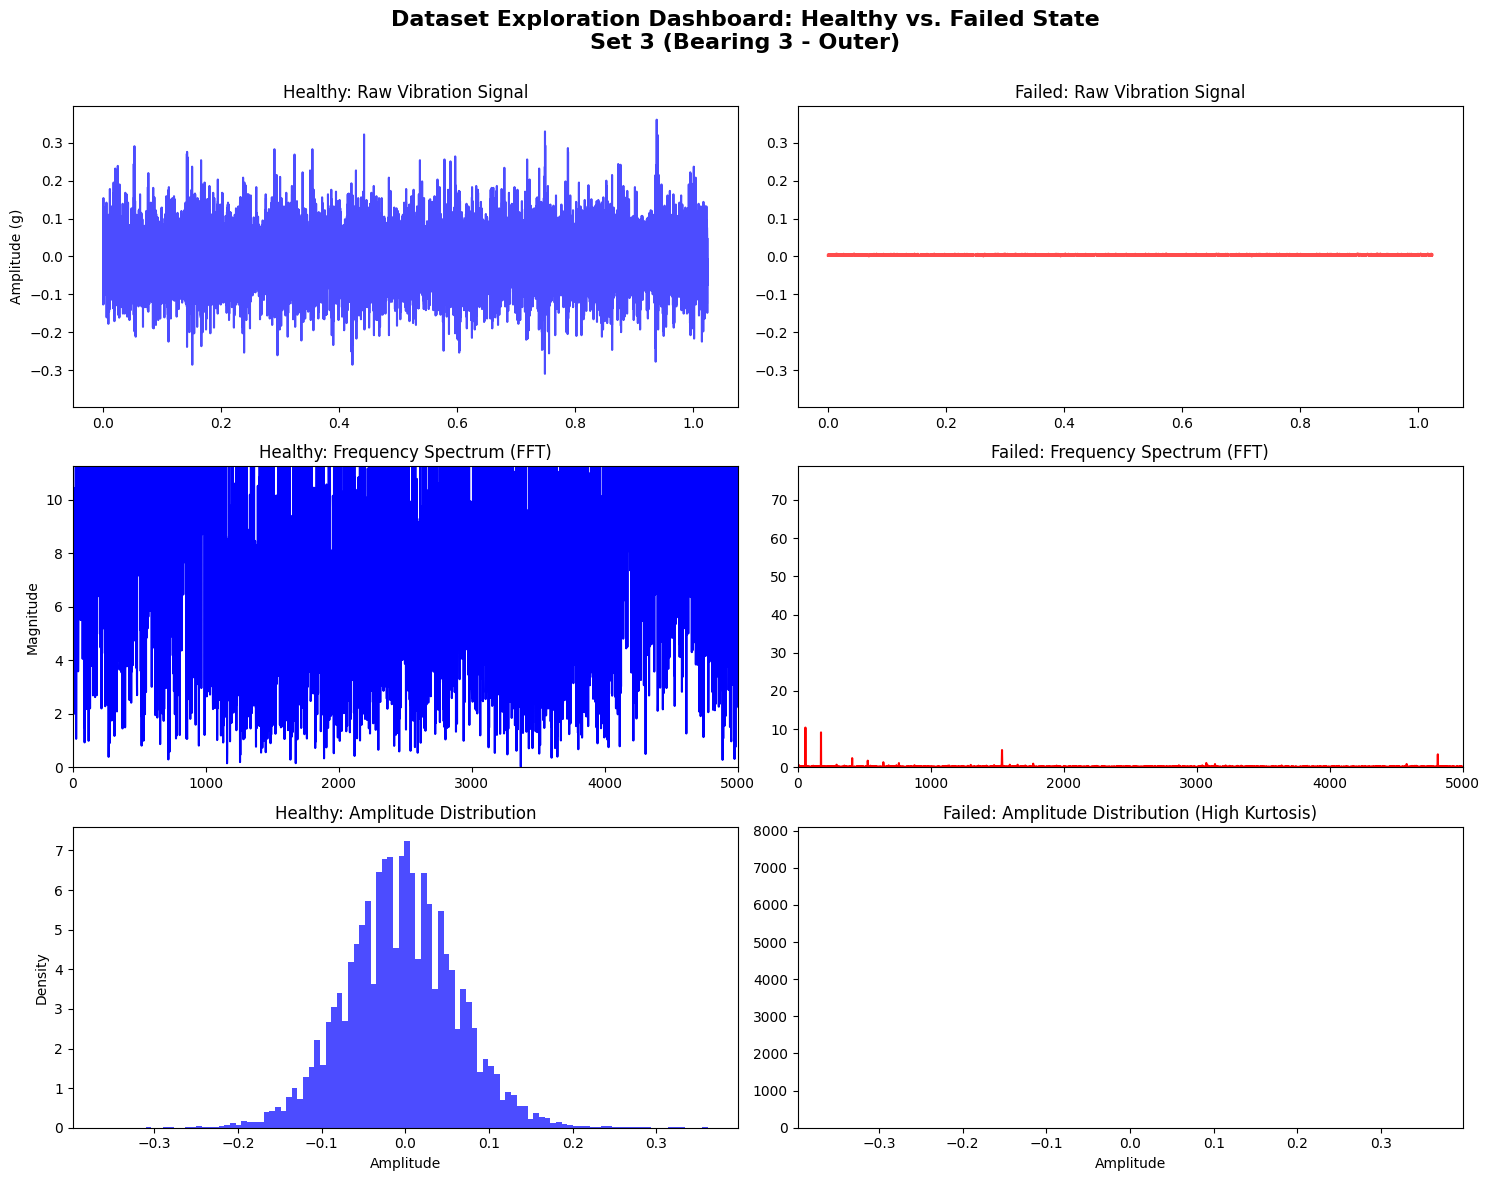

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- 1. Helper Function ---
def get_clean_folder_path(folder_path):
    if '3rd_test' in folder_path:
        deep_path = os.path.join(folder_path, '4th_test', 'txt')
        if os.path.exists(deep_path): return deep_path
        mid_path = os.path.join(folder_path, '4th_test')
        if os.path.exists(mid_path): return mid_path
        txt_path = os.path.join(folder_path, 'txt')
        if os.path.exists(txt_path): return txt_path
    if os.path.exists(os.path.join(folder_path, os.path.basename(folder_path))):
        return os.path.join(folder_path, os.path.basename(folder_path))
    return folder_path

# --- 2. Data Loader ---
def load_bearing_data(folder_path, col_idx):
    folder_path = get_clean_folder_path(folder_path)

    if not os.path.exists(folder_path):
        print(f"Warning: Folder '{folder_path}' not found.")
        return None, None, None, None

    valid_files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path)
                          if not f.startswith('.') and os.path.isfile(os.path.join(folder_path, f))])

    if len(valid_files) == 0:
        return None, None, None, None

    # Load First (Healthy) and Last (Failed) files
    def read_file(filepath):
        try:
            return pd.read_csv(filepath, sep='\t', header=None).iloc[:, col_idx].values
        except Exception:
            return pd.read_csv(filepath, delim_whitespace=True, header=None).iloc[:, col_idx].values

    healthy_sig = read_file(valid_files[0])
    failed_sig = read_file(valid_files[-1])

    return healthy_sig, failed_sig, valid_files[0], valid_files[-1]

# --- 3. Plotting Dashboard ---
def plot_informative_dashboard(dataset_name, dataset_path, col_idx):
    fs = 20000  # Sampling frequency

    print(f"Loading data for {dataset_name}...")
    healthy_sig, failed_sig, file_h, file_f = load_bearing_data(dataset_path, col_idx)

    if healthy_sig is None:
        print(f"Skipping {dataset_name} - no files found.")
        return

    N = len(healthy_sig)
    time_axis = np.linspace(0, N/fs, N)

    # Dynamic scaling based on the failed signal's max amplitude
    max_amp = max(np.max(np.abs(healthy_sig)), np.max(np.abs(failed_sig))) * 1.1

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle(f'Dataset Exploration Dashboard: Healthy vs. Failed State\n{dataset_name}', fontsize=16, fontweight='bold')

    # --- ROW 1: Time Domain ---
    axes[0, 0].plot(time_axis, healthy_sig, color='blue', alpha=0.7)
    axes[0, 0].set_title('Healthy: Raw Vibration Signal')
    axes[0, 0].set_ylabel('Amplitude (g)')
    axes[0, 0].set_ylim(-max_amp, max_amp)

    axes[0, 1].plot(time_axis, failed_sig, color='red', alpha=0.7)
    axes[0, 1].set_title('Failed: Raw Vibration Signal')
    axes[0, 1].set_ylim(-max_amp, max_amp)

    # --- ROW 2: Frequency Domain (FFT) ---
    yf_healthy = np.abs(fft(healthy_sig))[0:N//2]
    yf_failed = np.abs(fft(failed_sig))[0:N//2]
    xf = fftfreq(N, 1/fs)[0:N//2]

    max_fft = np.max(yf_failed)

    axes[1, 0].plot(xf, yf_healthy, color='blue')
    axes[1, 0].set_title('Healthy: Frequency Spectrum (FFT)')
    axes[1, 0].set_ylabel('Magnitude')
    axes[1, 0].set_xlim(0, 5000)
    axes[1, 0].set_ylim(0, max_fft * 0.15) # Scale to see healthy noise, but relative to failure peak

    axes[1, 1].plot(xf, yf_failed, color='red')
    axes[1, 1].set_title('Failed: Frequency Spectrum (FFT)')
    axes[1, 1].set_xlim(0, 5000)
    axes[1, 1].set_ylim(0, max_fft * 1.05)

    # --- ROW 3: Statistical Distribution ---
    axes[2, 0].hist(healthy_sig, bins=100, color='blue', alpha=0.7, density=True)
    axes[2, 0].set_title('Healthy: Amplitude Distribution')
    axes[2, 0].set_xlabel('Amplitude')
    axes[2, 0].set_ylabel('Density')
    axes[2, 0].set_xlim(-max_amp, max_amp)

    axes[2, 1].hist(failed_sig, bins=100, color='red', alpha=0.7, density=True)
    axes[2, 1].set_title('Failed: Amplitude Distribution (High Kurtosis)')
    axes[2, 1].set_xlabel('Amplitude')
    axes[2, 1].set_xlim(-max_amp, max_amp)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

# --- 4. Execution ---
base_path = '/content/drive/MyDrive/Colab Notebooks' # Fixed typo here

datasets = {
    'Set 1 (Bearing 3 - Inner)': {'path': f'{base_path}/1st_test', 'col': 4},
    'Set 2 (Bearing 1 - Outer)': {'path': f'{base_path}/2nd_test', 'col': 0},
    'Set 3 (Bearing 3 - Outer)': {'path': f'{base_path}/3rd_test', 'col': 2}
}

# Loop through and generate a dashboard for each dataset
for name, info in datasets.items():
    plot_informative_dashboard(name, info['path'], info['col'])

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import spectrogram
from scipy.stats import kurtosis
from tqdm.auto import tqdm


# ============================================================
# 1. Paths and configuration
# ============================================================

base_path = "/content/drive/MyDrive/Colab Notebooks"

output_root = os.path.join(base_path, "rul_dataset")
image_dir = os.path.join(output_root, "images")
labels_path = os.path.join(output_root, "labels.csv")

os.makedirs(image_dir, exist_ok=True)

datasets = {
    "Set_1": {"path": os.path.join(base_path, "1st_test")},
    "Set_2": {"path": os.path.join(base_path, "2nd_test")},
    "Set_3": {"path": os.path.join(base_path, "3rd_test")},
}

FS = 20_000
NPERSEG = 512
MAX_FREQUENCY = 2_000


# ============================================================
# 2. Helper functions
# ============================================================

def get_clean_folder_path(folder_path):
    """
    Resolve the unusual folder nesting in the third test.
    """
    if "3rd_test" in folder_path:
        candidates = [
            os.path.join(folder_path, "4th_test", "txt"),
            os.path.join(folder_path, "4th_test"),
            os.path.join(folder_path, "txt"),
        ]

        for candidate in candidates:
            if os.path.isdir(candidate):
                return candidate

    nested = os.path.join(
        folder_path,
        os.path.basename(folder_path)
    )

    if os.path.isdir(nested):
        return nested

    return folder_path


def natural_key(text):
    """
    Natural sorting:
    file_2 comes before file_10.
    """
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", text)
    ]


def read_measurement(filepath):
    """
    Read tab-separated or whitespace-separated measurement files.
    """
    try:
        data = pd.read_csv(
            filepath,
            sep="\t",
            header=None
        )
    except Exception:
        data = pd.read_csv(
            filepath,
            sep=r"\s+",
            header=None
        )

    # Ensure all values are numeric.
    data = data.apply(pd.to_numeric, errors="coerce")
    data = data.dropna(axis=1, how="all")
    data = data.interpolate(
        axis=0,
        limit_direction="both"
    )

    return data


def calculate_features(signal):
    """
    Compute useful scalar condition-monitoring features.
    """
    signal = np.asarray(signal, dtype=np.float32)

    rms = np.sqrt(np.mean(np.square(signal)))
    standard_deviation = np.std(signal)
    peak = np.max(np.abs(signal))
    peak_to_peak = np.ptp(signal)

    crest_factor = peak / (rms + 1e-8)

    signal_kurtosis = kurtosis(
        signal,
        fisher=False,
        bias=False
    )

    return {
        "rms": float(rms),
        "std": float(standard_deviation),
        "peak": float(peak),
        "peak_to_peak": float(peak_to_peak),
        "crest_factor": float(crest_factor),
        "kurtosis": float(signal_kurtosis),
    }


def create_spectrogram(signal):
    """
    Generate a log-power spectrogram.

    The signal is centered, but it is not divided by its own
    standard deviation. This avoids completely deleting amplitude
    progression from the input.
    """
    signal = np.asarray(signal, dtype=np.float32)

    centered_signal = signal - np.mean(signal)

    frequencies, times, power = spectrogram(
        centered_signal,
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NPERSEG // 2,
        scaling="density",
        mode="psd",
    )

    power_db = 10.0 * np.log10(power + 1e-12)

    frequency_mask = frequencies <= MAX_FREQUENCY
    power_db = power_db[frequency_mask, :]

    return power_db


# ============================================================
# 3. Scan each complete run and assign RUL
# ============================================================

records = []

print("Generating RUL spectrogram dataset...")

for dataset_name, dataset_info in datasets.items():

    folder_path = get_clean_folder_path(
        dataset_info["path"]
    )

    if not os.path.isdir(folder_path):
        print(
            f"Skipping {dataset_name}: "
            f"folder not found: {folder_path}"
        )
        continue

    file_names = [
        name
        for name in os.listdir(folder_path)
        if not name.startswith(".")
        and os.path.isfile(os.path.join(folder_path, name))
    ]

    file_names = sorted(
        file_names,
        key=natural_key
    )

    number_of_files = len(file_names)

    if number_of_files == 0:
        print(f"Skipping {dataset_name}: no files found.")
        continue

    print(
        f"{dataset_name}: "
        f"{number_of_files} chronological measurements"
    )
    print("First files:", file_names[:3])
    print("Last files: ", file_names[-3:])

    for file_index, filename in enumerate(
        tqdm(file_names, desc=dataset_name)
    ):
        filepath = os.path.join(
            folder_path,
            filename
        )

        try:
            data = read_measurement(filepath)
        except Exception as error:
            print(f"Could not read {filepath}: {error}")
            continue

        # Normalized RUL:
        # 1.0 = beginning of experiment
        # 0.0 = final measurement
        normalized_rul = (
            number_of_files - 1 - file_index
        ) / max(number_of_files - 1, 1)

        # File-level remaining measurement count.
        rul_measurements = (
            number_of_files - 1 - file_index
        )

        for channel_index in range(data.shape[1]):

            raw_signal = data.iloc[
                :, channel_index
            ].to_numpy(dtype=np.float32)

            if not np.all(np.isfinite(raw_signal)):
                continue

            features = calculate_features(raw_signal)
            spectrogram_db = create_spectrogram(raw_signal)

            image_name = (
                f"{dataset_name}_"
                f"ch{channel_index:02d}_"
                f"measurement{file_index:06d}.png"
            )

            image_path = os.path.join(
                image_dir,
                image_name
            )

            # Save with fixed display limits if possible.
            # Fixed limits make image intensity comparable
            # between samples.
            plt.imsave(
                image_path,
                spectrogram_db,
                cmap="magma",
                origin="lower",
                vmin=-120,
                vmax=20,
            )

            records.append({
                "image_path": image_path,
                "image_name": image_name,
                "dataset": dataset_name,
                "source_file": filename,
                "file_index": file_index,
                "channel": channel_index,
                "number_of_files": number_of_files,
                "normalized_rul": float(normalized_rul),
                "rul_measurements": int(rul_measurements),
                **features,
            })


# ============================================================
# 4. Save regression target manifest
# ============================================================

labels_df = pd.DataFrame(records)

if labels_df.empty:
    raise RuntimeError(
        "No images were generated. Check source paths "
        "and source-file formatting."
    )

labels_df.to_csv(
    labels_path,
    index=False
)

print("\nDataset generation finished.")
print(f"Images: {image_dir}")
print(f"Labels: {labels_path}")
print(f"Number of images: {len(labels_df):,}")
print("\nRUL summary:")
print(
    labels_df["normalized_rul"].describe()
)

Generating RUL spectrogram dataset...
Set_1: 2156 chronological measurements
First files: ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13']
Last files:  ['2003.11.25.23.19.56', '2003.11.25.23.29.56', '2003.11.25.23.39.56']


Set_1:   0%|          | 0/2156 [00:00<?, ?it/s]

Set_2: 984 chronological measurements
First files: ['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39']
Last files:  ['2004.02.19.06.02.39', '2004.02.19.06.12.39', '2004.02.19.06.22.39']


Set_2:   0%|          | 0/984 [00:00<?, ?it/s]

Set_3: 6324 chronological measurements
First files: ['2004.03.04.09.27.46', '2004.03.04.09.32.46', '2004.03.04.09.42.46']
Last files:  ['2004.04.18.02.22.55', '2004.04.18.02.32.55', '2004.04.18.02.42.55']


Set_3:   0%|          | 0/6324 [00:00<?, ?it/s]


Dataset generation finished.
Images: /content/drive/MyDrive/Colab Notebooks/rul_dataset/images
Labels: /content/drive/MyDrive/Colab Notebooks/rul_dataset/labels.csv
Number of images: 46,480

RUL summary:
count    46480.000000
mean         0.500000
std          0.288778
min          0.000000
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: normalized_rul, dtype: float64


In [ ]:
import pandas as pd

labels_path = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "rul_dataset/labels.csv"
)

df = pd.read_csv(labels_path)

split_mapping = {
    "Set_1": "train",
    "Set_2": "valid",
    "Set_3": "test",
}

df["split"] = df["dataset"].map(split_mapping)

df.to_csv(
    labels_path,
    index=False
)

print(
    df.groupby(["split", "dataset"])
      .size()
)

split  dataset
test   Set_3      25296
train  Set_1      17248
valid  Set_2       3936
dtype: int64


# How the Regression Data Loader Works

Here is a breakdown of the pipeline logic that converts the folder of loose spectrogram images into a structured, continuous data stream for neural network training.

### 1. Data Discovery and Sorting
*   **Recursive Search:** The script uses `Path(dataset_dir).rglob("*.png")` to scan through the `train`, `valid`, and `test` folders to find every generated spectrogram.
*   **Metadata Extraction:** It reads the filename (e.g., `Set_1_2004.02.19...png`) to identify which specific run-to-failure bearing test the image belongs to.
*   **Chronological Alignment:** Because you are predicting time-to-failure, the order of the files is paramount. The script sorts the files by dataset and filename to ensure the degradation sequence is perfectly sequential.

### 2. Remaining Useful Life (RUL) Calculation
Instead of using categorical bins ("healthy", "failing"), a regression model requires a continuous numerical target. The script calculates the exact percentage of life remaining for each snapshot using this specific mathematical formula:

$$RUL = 1.0 - \left( \frac{i}{N - 1} \right)$$

*   $i$ represents the chronological index of the current file.
*   $N$ represents the total number of files in that specific dataset.

> **Example:** In a dataset of 1,000 files, the 500th file represents the halfway point of the bearing's life. The formula computes an RUL target of **0.5** (or 50% life remaining). The final file is assigned **0.0**.

---

### 3. The TensorFlow Data Pipeline (`tf.data`)
Loading over 7,000 images into RAM simultaneously would crash most Colab environments. The script builds a pipeline to stream the data directly from the hard drive to the model in small, manageable chunks.

*   **Decoding & Resizing:** As each batch is called, it reads the `.png` file, decodes the pixel data, and resizes it to a standardized **128x128** grid.
*   **Pixel Normalization:** It scales the standard 0-255 RGB pixel values down to a **[0, 1]** range. Neural networks converge much faster and more reliably on normalized inputs.
*   **Batching & Prefetching:** It bundles the images and their corresponding RUL targets into batches (e.g., 32 at a time). While the neural network is calculating the math for Batch 1, the pipeline automatically fetches and prepares Batch 2 in the background using `tf.data.AUTOTUNE`, eliminating hardware bottlenecks.

In [ ]:
import tensorflow as tf
import pandas as pd

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

labels_path = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "rul_dataset/labels.csv"
)

df = pd.read_csv(labels_path)

train_df = df[df["split"] == "train"].copy()
valid_df = df[df["split"] == "valid"].copy()
test_df = df[df["split"] == "test"].copy()


def load_sample(image_path, target):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(
        image,
        channels=3
    )
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    target = tf.cast(
        target,
        tf.float32
    )
    target = tf.reshape(
        target,
        shape=(1,)
    )

    return image, target


def make_dataset(frame, training=False):
    paths = frame["image_path"].to_numpy()
    targets = frame[
        "normalized_rul"
    ].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, targets)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(frame),
            seed=42,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_sample,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_ds = make_dataset(
    train_df,
    training=True
)

valid_ds = make_dataset(
    valid_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

print("Train images:", len(train_df))
print("Valid images:", len(valid_df))
print("Test images: ", len(test_df))

Train images: 17248
Valid images: 3936
Test images:  25296


In [ ]:
# ============================================================
# COMPLETE RUL CNN TRAINING CELL
# Assumes:
#   1. Google Drive is already mounted
#   2. rul_dataset/labels.csv already exists
#   3. labels.csv contains:
#      image_path, dataset, normalized_rul, split
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models


# ============================================================
# 1. Reproducibility and configuration
# ============================================================

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 40
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

labels_path = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "rul_dataset/labels.csv"
)

model_path = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "best_rul_cnn_v2.keras"
)

predictions_path = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "rul_test_predictions.csv"
)


# ============================================================
# 2. Read and validate labels.csv
# ============================================================

if not os.path.exists(labels_path):
    raise FileNotFoundError(
        f"labels.csv was not found:\n{labels_path}\n"
        "Run the RUL spectrogram-generation cell first."
    )

df = pd.read_csv(labels_path)

required_columns = {
    "image_path",
    "dataset",
    "normalized_rul"
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing columns in labels.csv: {sorted(missing_columns)}"
    )

# Add or overwrite the run-level split.
# This prevents neighboring measurements from the same run
# appearing in both training and validation/test data.
split_mapping = {
    "Set_1": "train",
    "Set_2": "valid",
    "Set_3": "test"
}

df["split"] = df["dataset"].map(split_mapping)

if df["split"].isna().any():
    unknown_datasets = df.loc[
        df["split"].isna(),
        "dataset"
    ].unique()

    raise ValueError(
        f"No split mapping exists for: {unknown_datasets}"
    )

# Ensure targets are numeric.
df["normalized_rul"] = pd.to_numeric(
    df["normalized_rul"],
    errors="coerce"
)

if df["normalized_rul"].isna().any():
    raise ValueError(
        "normalized_rul contains missing or non-numeric values."
    )

if not df["normalized_rul"].between(0.0, 1.0).all():
    invalid_range = df.loc[
        ~df["normalized_rul"].between(0.0, 1.0),
        "normalized_rul"
    ]

    raise ValueError(
        "normalized_rul must be between 0 and 1. "
        f"Observed range: {invalid_range.min()} to "
        f"{invalid_range.max()}"
    )

# Confirm every referenced image exists.
exists_mask = df["image_path"].map(os.path.exists)

if not exists_mask.all():
    missing_count = int((~exists_mask).sum())
    missing_examples = df.loc[
        ~exists_mask,
        "image_path"
    ].head(5).tolist()

    raise FileNotFoundError(
        f"{missing_count} spectrogram images are missing.\n"
        f"Examples:\n{missing_examples}"
    )

# Save the split column permanently.
df.to_csv(labels_path, index=False)

train_df = (
    df[df["split"] == "train"]
    .reset_index(drop=True)
    .copy()
)

valid_df = (
    df[df["split"] == "valid"]
    .reset_index(drop=True)
    .copy()
)

test_df = (
    df[df["split"] == "test"]
    .reset_index(drop=True)
    .copy()
)

if train_df.empty or valid_df.empty or test_df.empty:
    raise ValueError(
        "At least one split is empty. Check dataset names "
        "and split_mapping."
    )

print("Dataset split:")
print(df.groupby(["split", "dataset"]).size())

print("\nRUL ranges:")
print(
    df.groupby("split")["normalized_rul"]
      .agg(["min", "max", "mean", "std"])
)


# ============================================================
# 3. TensorFlow image loader
# ============================================================

def load_rul_sample(image_path, normalized_rul):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_png(
        image_bytes,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear"
    )

    # Scale exactly once from [0, 255] to [0, 1].
    image = tf.cast(image, tf.float32) / 255.0

    target = tf.cast(
        normalized_rul,
        tf.float32
    )

    # Match model output shape: (batch_size, 1)
    target = tf.reshape(target, (1,))

    return image, target


def make_rul_dataset(frame, training=False):
    image_paths = frame[
        "image_path"
    ].astype(str).to_numpy()

    targets = frame[
        "normalized_rul"
    ].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, targets)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(frame), 10_000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_rul_sample,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_rul_dataset(
    train_df,
    training=True
)

valid_ds = make_rul_dataset(
    valid_df,
    training=False
)

test_ds = make_rul_dataset(
    test_df,
    training=False
)


# ============================================================
# 4. Dataset sanity checks
# ============================================================

print("\nTensorFlow dataset batches:")
print(
    "Train:",
    tf.data.experimental.cardinality(train_ds).numpy()
)
print(
    "Valid:",
    tf.data.experimental.cardinality(valid_ds).numpy()
)
print(
    "Test: ",
    tf.data.experimental.cardinality(test_ds).numpy()
)

for sample_images, sample_targets in train_ds.take(1):
    print("\nFirst training batch:")
    print("Image shape:", sample_images.shape)
    print("Target shape:", sample_targets.shape)
    print(
        "Image range:",
        float(tf.reduce_min(sample_images)),
        "to",
        float(tf.reduce_max(sample_images))
    )
    print(
        "Target range:",
        float(tf.reduce_min(sample_targets)),
        "to",
        float(tf.reduce_max(sample_targets))
    )

    if sample_images.shape[-1] != 3:
        raise ValueError(
            "CNN expects three-channel images."
        )

    if (
        float(tf.reduce_min(sample_images)) < 0.0
        or float(tf.reduce_max(sample_images)) > 1.0
    ):
        raise ValueError(
            "Images are not scaled to the [0, 1] range."
        )


# ============================================================
# 5. RUL regression CNN
# ============================================================

def build_rul_cnn_v2(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(
            32,
            kernel_size=(3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        layers.Conv2D(
            64,
            kernel_size=(3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        layers.Conv2D(
            128,
            kernel_size=(3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.3),

        # normalized_rul is constrained to [0, 1]
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model


tf.keras.backend.clear_session()

model_v2 = build_rul_cnn_v2()

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    # Robust regression loss for normalized RUL.
    loss=tf.keras.losses.Huber(
        delta=0.1
    ),

    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

print("\nModel architecture:")
model_v2.summary()


# ============================================================
# 6. Training callbacks
# ============================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

terminate_nan = tf.keras.callbacks.TerminateOnNaN()


# ============================================================
# 7. Train
# ============================================================

print("\nStarting RUL regression training...")

history_v2 = model_v2.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        terminate_nan
    ],
    verbose=1
)


# ============================================================
# 8. Load and evaluate the best model
# ============================================================

best_model = tf.keras.models.load_model(
    model_path
)

test_metrics = best_model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1
)

print("\nBest model test results on Set_3:")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.6f}")


# ============================================================
# 9. Generate and save test predictions
# ============================================================

predicted_rul = best_model.predict(
    test_ds,
    verbose=1
).reshape(-1)

if len(predicted_rul) != len(test_df):
    raise RuntimeError(
        "Prediction count does not match test metadata."
    )

test_predictions = test_df.copy()

test_predictions["predicted_normalized_rul"] = (
    predicted_rul
)

test_predictions["absolute_error"] = np.abs(
    test_predictions["normalized_rul"]
    - test_predictions["predicted_normalized_rul"]
)

test_predictions.to_csv(
    predictions_path,
    index=False
)

print(
    "\nMean test absolute error:",
    test_predictions["absolute_error"].mean()
)

print(f"\nBest model saved to:\n{model_path}")
print(f"\nTest predictions saved to:\n{predictions_path}")

print("\nPrediction preview:")
print(
    test_predictions[
        [
            "dataset",
            "file_index",
            "channel",
            "normalized_rul",
            "predicted_normalized_rul",
            "absolute_error"
        ]
    ].head(10)
)

Dataset split:
split  dataset
test   Set_3      25296
train  Set_1      17248
valid  Set_2       3936
dtype: int64

RUL ranges:
       min  max  mean       std
split                          
test   0.0  1.0   0.5  0.288726
train  0.0  1.0   0.5  0.288817
valid  0.0  1.0   0.5  0.289005

TensorFlow dataset batches:
Train: 539
Valid: 123
Test:  791

First training batch:
Image shape: (32, 224, 224, 3)
Target shape: (32, 1)
Image range: 0.0006829953636042774 to 0.8129550814628601
Target range: 0.4477958381175995 to 0.9628770351409912

Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,561 (431.88 KB)

 Trainable params: 110,113 (430.13 KB)

 Non-trainable params: 448 (1.75 KB)


Starting RUL regression training...
Epoch 1/40
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0151 - mae: 0.1962 - rmse: 0.2336
Epoch 1: val_loss improved from None to 0.01878, saving model to /content/drive/MyDrive/Colab Notebooks/best_rul_cnn_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_rul_cnn_v2.keras
539/539 ━━━━━━━━━━━━━━━━━━━━ 103s 167ms/step - loss: 0.0164 - mae: 0.2091 - rmse: 0.2522 - val_loss: 0.0188 - val_mae: 0.2342 - val_rmse: 0.2733 - learning_rate: 0.0010
Epoch 2/40
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0153 - mae: 0.1983 - rmse: 0.2361
Epoch 2: val_loss did not improve from 0.01878
539/539 ━━━━━━━━━━━━━━━━━━━━ 117s 136ms/step - loss: 0.0162 - mae: 0.2071 - rmse: 0.2498 - val_loss: 0.0292 - val_mae: 0.3372 - val_rmse: 0.4101 - learning_rate: 0.0010
Epoch 3/40
539/539 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0154 - mae: 0.1991 - rmse: 0.2361
Epoch 3: val_loss did not improve from 0.01878
539/539 ━━━━━━━

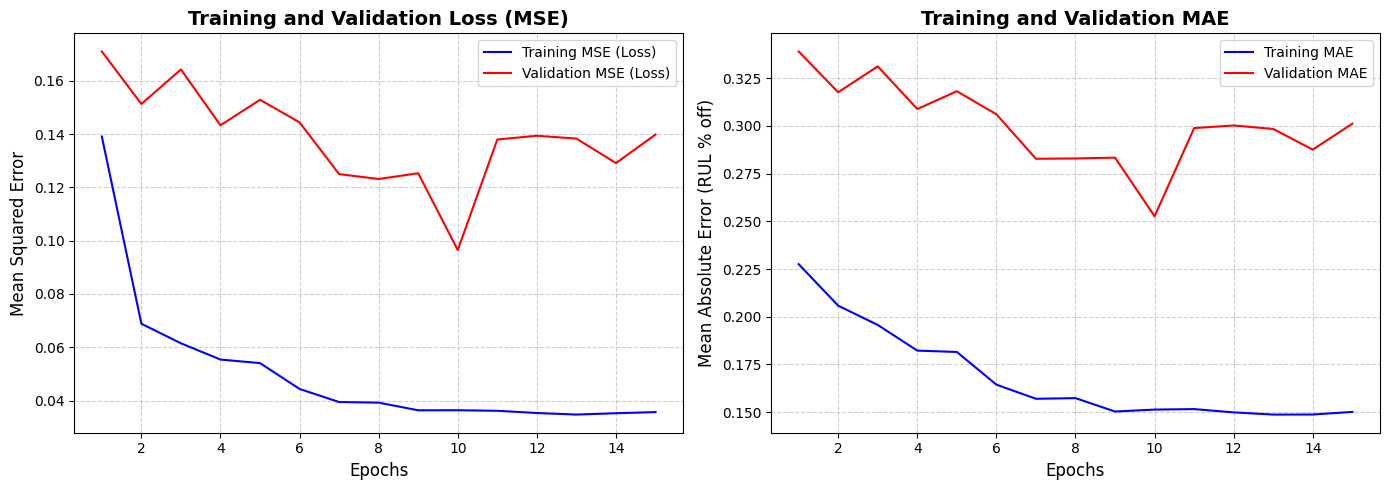

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract the metrics from the training history
    mse = history.history['loss']
    val_mse = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(mse) + 1)

    # Set up the plot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Mean Squared Error (Loss) ---
    ax1.plot(epochs, mse, 'b-', label='Training MSE (Loss)')
    ax1.plot(epochs, val_mse, 'r-', label='Validation MSE (Loss)')
    ax1.set_title('Training and Validation Loss (MSE)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Mean Squared Error', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Plot 2: Mean Absolute Error (MAE) ---
    ax2.plot(epochs, mae, 'b-', label='Training MAE')
    ax2.plot(epochs, val_mae, 'r-', label='Validation MAE')
    ax2.set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error (RUL % off)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Execute the plotting function
plot_training_history(history)

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_mae = model.evaluate(test_loader)

print("\n" + "="*40)
print(f" FINAL TEST RESULTS")
print("="*40)
print(f"Test Mean Squared Error (MSE): {test_loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"On average, RUL predictions are off by: {test_mae * 100:.2f}%")
print("="*40)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0962 - mae: 0.2510

 FINAL TEST RESULTS
Test Mean Squared Error (MSE): 0.0962
Test Mean Absolute Error (MAE): 0.2510
On average, RUL predictions are off by: 25.10%
